In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Read Image Dataset

TARGET_PATH = "images/target/"
SOURCE_PATH = "images/source/"

# target image
target = cv2.imread(TARGET_PATH + 'hina.png')
target_rgb = cv2.cvtColor(target, cv2.COLOR_BGR2RGB)

# source image
source_data = []
for file_name in os.listdir(SOURCE_PATH):
    file_path = SOURCE_PATH + file_name
    img = cv2.imread(file_path)
    source_data.append(img)

print("Target image :", target_rgb.shape)
print("Jumlah Sourvce img: ", len(source_data))

Target image : (456, 404, 3)
Jumlah Sourvce img:  12


In [4]:
# Preprocessing Target

gray_target = cv2.cvtColor(target, cv2.COLOR_BGR2GRAY)
gray_target = cv2.GaussianBlur(gray_target, (3, 3), 0)
# gray_target = cv2.medianBlur(gray_target, 3)
# gray_target = cv2.bilateralFilter(gray_target, 0, 75, 75)

# pake biar smooth warnanya
gray_target = cv2.equalizeHist(gray_target)

In [ ]:
# Prepare Methods
methods = ["SIFT", "AKAZE", "ORB"]
ratio_list = [0.45, 0.5, 0.55]

best_matches = 0
best_matches_data = None
best_method = None
best_ratio = None

In [10]:
# Try all methods

for method in methods:
    print("\nMethod: ", method)

    # pilih detector
    if method == "SIFT":
        detector = cv2.SIFT_create()
    elif method == "AKAZE":
        detector = cv2.AKAZE_create()
    elif method == "ORB":
        detector = cv2.ORB_create()

    # detect target keypoint & descriptor
    target_kp, target_desc = detector.detectAndCompute(gray_target, None)

    if target_desc is None:
        print("Descriptor target tidak ditemukan")
        continue

    # ubah tipe descriptor
    if method == "SIFT":
        target_desc = np.float32(target_desc) # buat SIFT
    else:
        target_desc = np.uint8(target_desc) # buat AKAZE dan ORB

    # coba beberapa nilai ratio
    for ratio in ratio_list:
        print(" Lowes't Ratio: ", ratio)

        # loop matching dll
        for idx, img in enumerate(source_data):
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # preprocessing source
            gray_source = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            gray_source = cv2.GaussianBlur(gray_source, (3, 3), 0)
            # gray_source = cv2.medianBlur(gray_source, 3)
            # gray_source = cv2.bilateralFilter(gray_source, 0, 75, 75)
            gray_source = cv2.equalizeHist(gray_source)

            # detect source keypoint & description
            source_kp, source_desc = detector.detectAndCompute(gray_source, None)

            if source_desc is None:
                continue

            # ubah tipe descriptor
            if method == "SIFT":
                source_desc = np.float32(source_desc)
            else:
                source_desc = np.uint8(source_desc)

            # FLANN Matcher
            if method == "SIFT":
                flann = cv2.FlannBasedMatcher(
                    dict(algorithm=1, trees=5), 
                    dict(checks=50)
                )
            else:
                flann = cv2.FlannBasedMatcher(
                    dict(algorithm=6, table_number=6, key_size=12, multi_probe_level=1),
                    dict(checks=50)
                )

            # matching
            matches = flann.knnMatch(target_desc, source_desc, k=2)
            matchesmask = [[0, 0] for _ in range(len(matches))]

            curr_matches = 0

            # Lowe's Ratio test
            for i, match_pair in enumerate(matches):
                if len(match_pair) == 2:
                    fm, sm = match_pair
                    if fm.distance < ratio * sm.distance:
                        matchesmask[i] = [1, 0]
                        curr_matches += 1

            print(" ", os.listdir(SOURCE_PATH), ":", curr_matches, "good matches")

            # simpan hasil terbaik global
            if curr_matches > best_matches:
                best_matches = curr_matches
                best_method = method
                best_ratio = ratio
                best_matches_data = {
                    'image_data': img_rgb,
                    'keypoint': source_kp,
                    'descriptor': source_desc,
                    'match': matches,
                    'matchesmask': matchesmask,
                    'filename': os.listdir(SOURCE_PATH)[idx],
                    'target_keypoint': target_kp
                }



Method:  SIFT
 Lowes't Ratio:  0.45
  ['plana.png', 'wakamo.png', 'hoshino.png', 'cherino.png', 'hikari.png', 'hina.png', 'yuuka.png', 'shiroko.png', 'misaki.png', 'miyako.png', 'kisaki.png', 'mika.png'] : 0 good matches
  ['plana.png', 'wakamo.png', 'hoshino.png', 'cherino.png', 'hikari.png', 'hina.png', 'yuuka.png', 'shiroko.png', 'misaki.png', 'miyako.png', 'kisaki.png', 'mika.png'] : 0 good matches
  ['plana.png', 'wakamo.png', 'hoshino.png', 'cherino.png', 'hikari.png', 'hina.png', 'yuuka.png', 'shiroko.png', 'misaki.png', 'miyako.png', 'kisaki.png', 'mika.png'] : 2 good matches
  ['plana.png', 'wakamo.png', 'hoshino.png', 'cherino.png', 'hikari.png', 'hina.png', 'yuuka.png', 'shiroko.png', 'misaki.png', 'miyako.png', 'kisaki.png', 'mika.png'] : 1 good matches
  ['plana.png', 'wakamo.png', 'hoshino.png', 'cherino.png', 'hikari.png', 'hina.png', 'yuuka.png', 'shiroko.png', 'misaki.png', 'miyako.png', 'kisaki.png', 'mika.png'] : 1 good matches
  ['plana.png', 'wakamo.png', 'hoshino

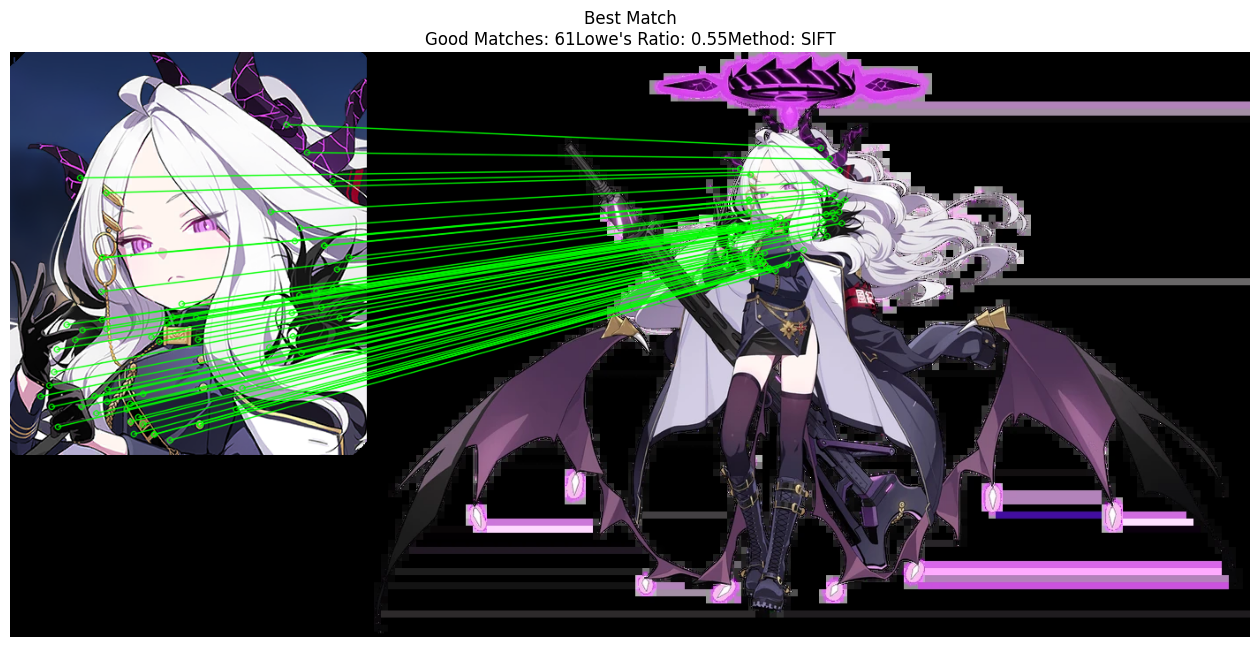


Best Method       : SIFT
Best Lowe Ratio   : 0.55
Best Source Image : hina.png
Good Matches      : 61


In [11]:
if best_matches_data is not None:
    result = cv2.drawMatchesKnn(
        target_rgb,
        best_matches_data['target_keypoint'],
        best_matches_data['image_data'],
        best_matches_data['keypoint'],
        best_matches_data['match'],
        None,
        matchesMask=best_matches_data['matchesmask'],
        matchColor=[0, 255, 0],
        flags = cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(16, 8))
    plt.imshow(result)
    plt.title("Best Match\n" + "Good Matches: " + str(best_matches) + "Lowe's Ratio: " + str(best_ratio) + "Method: " + best_method)
    plt.axis('off')
    plt.show()

    print("\nBest Method       :", best_method)
    print("Best Lowe Ratio   :", best_ratio)
    print("Best Source Image :", best_matches_data['filename'])
    print("Good Matches      :", best_matches)
else:
    print("Tidak ada matching yang berhasil ditemukan")